FIRST FIVE ROWS
                       State                    District        Grade  \
0  Andaman & Nicobar Islands              South Andamans  Prachesta-1   
1  Andaman & Nicobar Islands  Middle And North\nAndamans  Prachesta-1   
2  Andaman & Nicobar Islands                    Nicobars  Prachesta-1   
3             Andhra Pradesh                Vizianagaram  Prachesta-1   
4             Andhra Pradesh                      Guntur  Prachesta-1   

   Overall  Categories - 1.\nOutcome (290)  Categories - 2. ECT (90)  \
0      334                             133                        75   
1      322                             138                        73   
2      303                             130                        72   
3      341                             131                        66   
4      336                             134                        69   

   Categories - 3.\nIF&SE (51)  Categories - 4.\nSS&CP (35)  \
0                           27                   

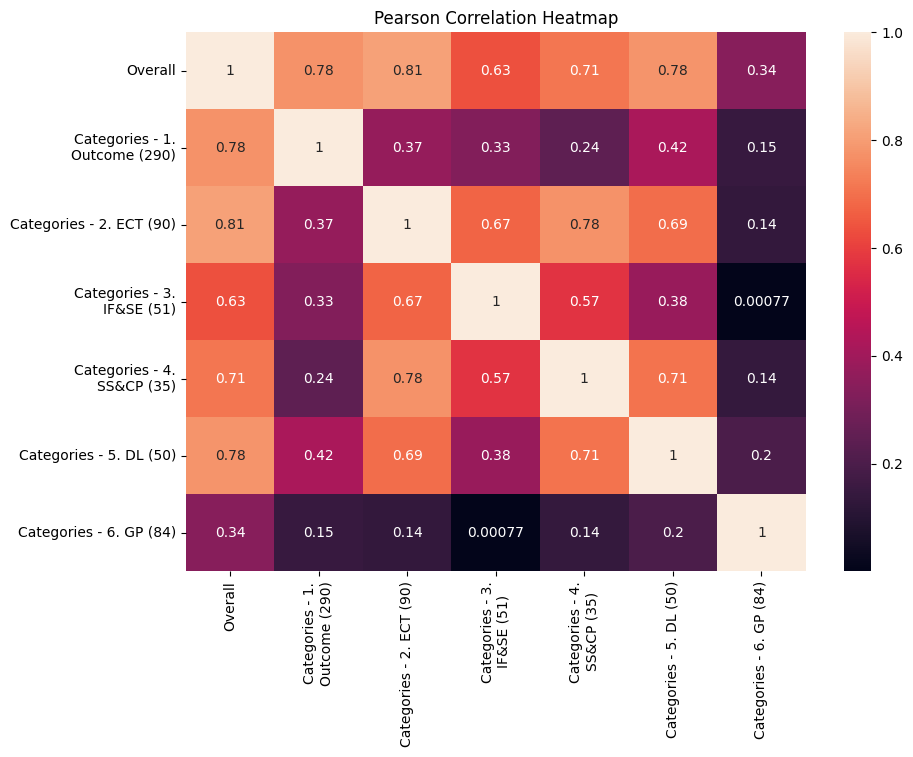


HIGHEST CORRELATIONS
Overall                         Overall                           1.000000
Categories - 1.\nOutcome (290)  Categories - 1.\nOutcome (290)    1.000000
Categories - 2. ECT (90)        Categories - 2. ECT (90)          1.000000
Categories - 4.\nSS&CP (35)     Categories - 4.\nSS&CP (35)       1.000000
Categories - 3.\nIF&SE (51)     Categories - 3.\nIF&SE (51)       1.000000
Categories - 5. DL (50)         Categories - 5. DL (50)           1.000000
Categories - 6. GP (84)         Categories - 6. GP (84)           1.000000
Categories - 2. ECT (90)        Overall                           0.810328
Overall                         Categories - 2. ECT (90)          0.810328
                                Categories - 5. DL (50)           0.779416
dtype: float64

SPEARMAN CORRELATION
                                 Overall  Categories - 1.\nOutcome (290)  \
Overall                         1.000000                        0.764917   
Categories - 1.\nOutcome (290)  0.76491

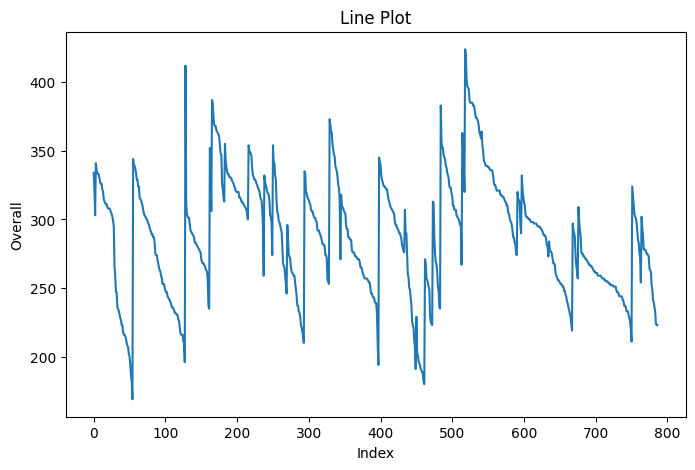

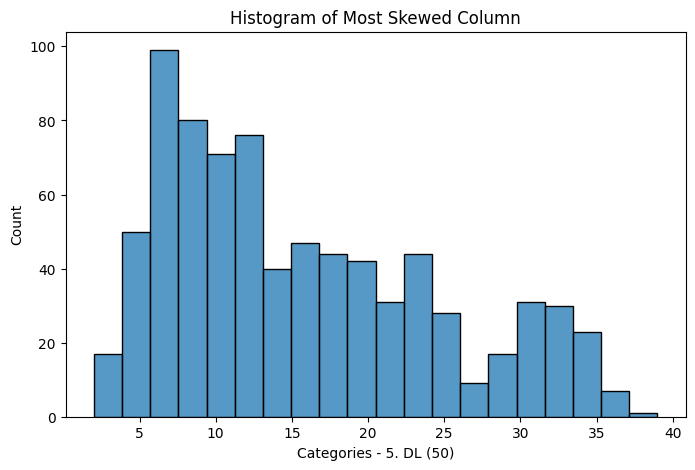

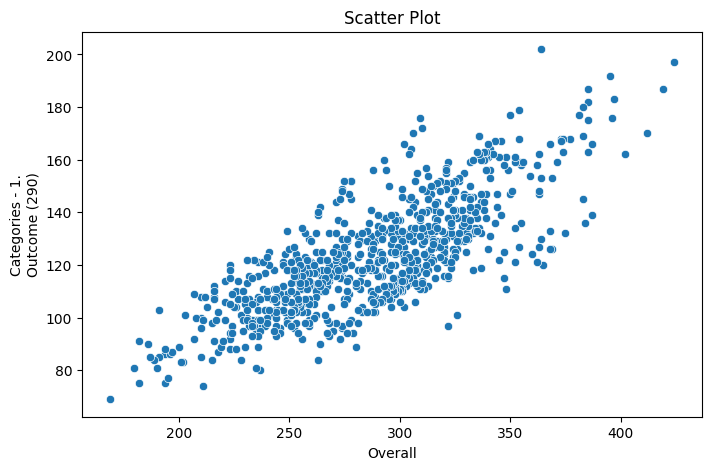

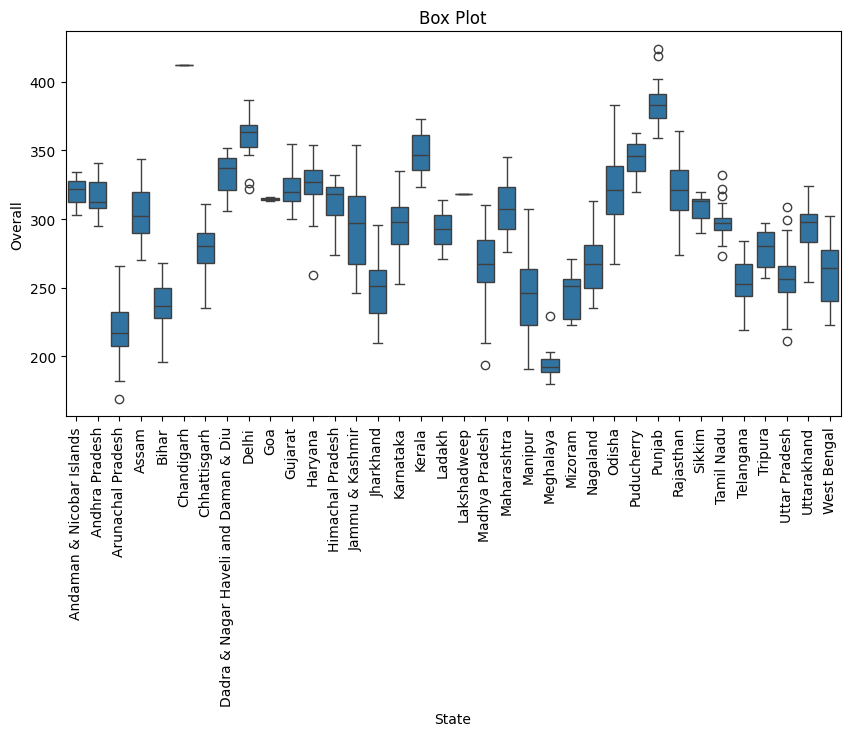

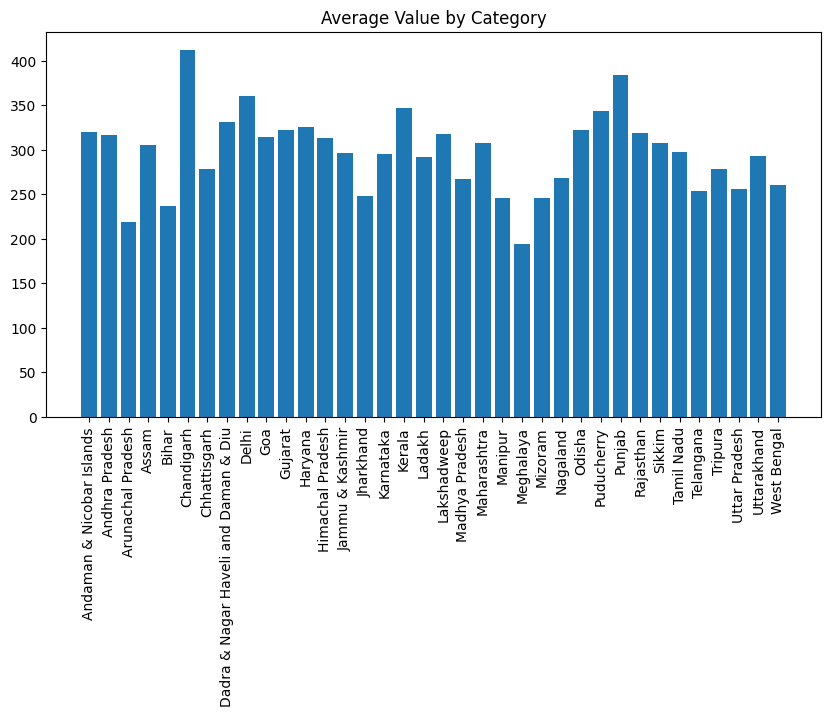


cleaned_data.csv created successfully


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


df = pd.read_csv("/content/datafile.csv")

print("FIRST FIVE ROWS")
print(df.head())

print("\nDATA TYPES")
print(df.dtypes)

print("\nDATASET SHAPE")
print(df.shape)

df.columns = df.columns.str.strip()

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage":
        (df.isnull().sum() / df.shape[0]) * 100
})

print("\nMISSING VALUE TABLE")
print(missing_table)


print("\nCOLUMNS WITH MORE THAN 20% NULL VALUES")

print(
    missing_table[
        missing_table["Missing Percentage"] > 20
    ]
)


numeric_columns = df.select_dtypes(
    include=np.number
).columns


for col in numeric_columns:

    null_percentage = (
        df[col].isnull().sum()
        /
        len(df)
    ) * 100

    if 0 < null_percentage < 20:

        df[col] = df[col].fillna(
            df[col].median()
        )



duplicate_count = df.duplicated().sum()

print("\nDUPLICATES FOUND:", duplicate_count)


rows_before = len(df)

df = df.drop_duplicates()


rows_removed = rows_before - len(df)


print(
    "ROWS REMOVED:",
    rows_removed
)


print("\nNULL VALUES AFTER DUPLICATE REMOVAL")

print(
    (df.isnull().sum()/len(df))*100
)



memory_before = (
    df.memory_usage(deep=True)
    .sum()
)

object_columns = df.select_dtypes(
    include="object"
).columns


for col in object_columns:

    if df[col].nunique() < 50:

        df[col] = df[col].astype(
            "category"
        )


memory_after = (
    df.memory_usage(deep=True)
    .sum()
)


print("\nMEMORY BEFORE:", memory_before)

print(
    "MEMORY AFTER:",
    memory_after
)

print(
    "MEMORY SAVED:",
    memory_before-memory_after
)

numeric_columns = df.select_dtypes(
    include=np.number
).columns


print("\nDESCRIPTIVE STATISTICS")

print(
    df[numeric_columns].describe()
)


skew_table = pd.DataFrame(
    {
        "Column": numeric_columns,
        "Skewness":
        [
            df[col].skew()
            for col in numeric_columns
        ]
    }
)


print("\nSKEWNESS VALUES")

print(skew_table)


most_skewed = (
    skew_table
    .iloc[
        skew_table["Skewness"]
        .abs()
        .idxmax()
    ]
)


print("\nMOST SKEWED COLUMN")

print(most_skewed)

print("\nOUTLIER ANALYSIS")


outlier_columns = list(
    numeric_columns[:2]
)


for col in outlier_columns:


    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1


    lower_limit = Q1-(1.5*IQR)

    upper_limit = Q3+(1.5*IQR)


    outliers = df[
        (df[col] < lower_limit)
        |
        (df[col] > upper_limit)
    ]


    print("\nColumn:", col)

    print("Q1:", Q1)

    print("Q3:", Q3)

    print("IQR:", IQR)

    print(
        "Lower Bound:",
        lower_limit
    )

    print(
        "Upper Bound:",
        upper_limit
    )

    print(
        "Number of Outliers:",
        len(outliers)
    )

top_two_skewed = (
    skew_table
    .sort_values(
        by="Skewness",
        key=abs,
        ascending=False
    )
    .head(2)
)


print("\nTOP TWO SKEWED COLUMNS")

print(top_two_skewed)



print("\nMEAN AND MEDIAN")


for col in top_two_skewed["Column"]:

    print("\nColumn:", col)

    print(
        "Mean:",
        df[col].mean()
    )

    print(
        "Median:",
        df[col].median()
    )


    df[col] = df[col].fillna(
        df[col].median()
    )


print("\nNULL AFTER IMPUTATION")

print(
    df[
        top_two_skewed["Column"]
    ]
    .isnull()
    .sum()
)

numeric_df = df.select_dtypes(
    include=np.number
)


pearson_corr = numeric_df.corr()


plt.figure(figsize=(10,7))


sns.heatmap(
    pearson_corr,
    annot=True
)


plt.title(
    "Pearson Correlation Heatmap"
)


plt.show()


corr_pairs = (
    pearson_corr
    .abs()
    .stack()
    .sort_values(
        ascending=False
    )
)


print("\nHIGHEST CORRELATIONS")

print(
    corr_pairs.head(10)
)



spearman_corr = numeric_df.corr(
    method="spearman"
)


print("\nSPEARMAN CORRELATION")

print(spearman_corr)



difference = (
    spearman_corr -
    pearson_corr
).abs()


print(
    "\nTOP 3 DIFFERENCES"
)


print(
    difference
    .stack()
    .sort_values(
        ascending=False
    )
    .head(3)
)


categorical_columns = df.select_dtypes(
    include="category"
).columns


if len(categorical_columns) > 0:


    category_col = categorical_columns[0]

    numeric_col = numeric_columns[0]


    group_result = df.groupby(
        category_col,
    observed=True
    )[numeric_col].agg(
        [
            "mean",
            "std",
            "count"
        ]
    )


    print("\nGROUP AGGREGATION")

    print(group_result)


os.makedirs(
    "plots",
    exist_ok=True
)


numeric1 = numeric_columns[0]


# Line Plot

plt.figure(figsize=(8,5))

plt.plot(
    df.index,
    df[numeric1]
)

plt.title(
    "Line Plot"
)

plt.xlabel(
    "Index"
)

plt.ylabel(
    numeric1
)

plt.savefig(
    "plots/line_plot.png"
)

plt.show()



# Histogram

plt.figure(figsize=(8,5))

sns.histplot(
    df[most_skewed["Column"]],
    bins=20
)

plt.title(
    "Histogram of Most Skewed Column"
)

plt.savefig(
    "plots/histogram.png"
)

plt.show()



# Scatter Plot

if len(numeric_columns) >= 2:

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        data=df,
        x=numeric_columns[0],
        y=numeric_columns[1]
    )


    plt.title(
        "Scatter Plot"
    )

    plt.savefig(
        "plots/scatter_plot.png"
    )

    plt.show()



# Box Plot

if len(categorical_columns)>0:


    plt.figure(figsize=(10,5))


    sns.boxplot(
        data=df,
        x=categorical_columns[0],
        y=numeric_columns[0]
    )


    plt.xticks(
        rotation=90
    )


    plt.title(
        "Box Plot"
    )


    plt.savefig(
        "plots/box_plot.png"
    )


    plt.show()



# Bar Chart

if len(categorical_columns)>0:


    bar_data = df.groupby(categorical_columns[0],
    observed=True
    )[numeric_columns[0]].mean()


    plt.figure(figsize=(10,5))


    plt.bar(
        bar_data.index.astype(str),
        bar_data.values
    )


    plt.xticks(
        rotation=90
    )


    plt.title(
        "Average Value by Category"
    )


    plt.savefig(
        "plots/bar_chart.png"
    )


    plt.show()



df.to_csv(
    "cleaned_data.csv",
    index=False
)


print(
    "\ncleaned_data.csv created successfully"
)